In [1]:
import re
import sys
import json
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from us import states
from census import Census

import useful
from setup import CENSUS_API_KEY

target_years = [2024]

In [2]:
# metadata: https://api.census.gov/data/2024/acs/acs5/groups/B25036.json
# helper functions for age-related variables
def _get_b25036_metadata(year):
    """
    Download universal ACS metadata and filter for B25036 variables.

    This endpoint is stable across ACS vintages.
    """

    url = f"https://api.census.gov/data/{year}/acs/acs5/groups/B25036.json"+"?key="+CENSUS_API_KEY

    response = requests.get(url)
    response.raise_for_status()

    all_variables = response.json().get("variables", {})

    b25036_metadata = {
        variable: info
        for variable, info in all_variables.items()
        if (
            variable.startswith("B25036_") and variable.endswith("E") 
            )
    }

    return b25036_metadata


def _parse_construction_range(label):

    if not isinstance(label, str):
        return None

    normalized = (
        label.lower()
        .replace("-", " ")
        .replace("—", " ")
        .replace("–", " ")
    )

    built_match = re.search(r"built (.*)", normalized)

    if built_match is None:
        return None

    built_text = built_match.group(1)

    # Built aaaa to bbbb
    match = re.search(r"(\d{4}) to (\d{4})", built_text)
    if match:
        return int(match.group(1)), int(match.group(2))

    # Built xxxx or later
    match = re.search(r"(\d{4}) or later", built_text)
    if match:
        return int(match.group(1)), None

    # Built yyyy or earlier
    match = re.search(r"(\d{4}) or earlier", built_text)
    if match:
        return None, int(match.group(1))

    return None


def _get_relevant_variables(year) -> dict:
    """
    Construct a metadata dictionary for renter-occupied construction periods.
    """

    # universe, 
    metadata = _get_b25036_metadata(year)

    parsed_variables = {}

    for variable, info in metadata.items():

        label = info.get("label", "")
        # print("\n", label, "\n")

        # Restrict to renter-occupied housing units
        if "Renter occupied" not in label:
            continue

        parsed_range = _parse_construction_range(label)
        # print("\n", parsed_range, "\n")

        if parsed_range is None:
            continue

        start_year, end_year = parsed_range

        def rename_var(start_year, end_year):
            if start_year is None:
                return "built_pre_" + str(end_year)
            
            if end_year is None:
                return "built_" + str(start_year) + "_to_" + str(year)
            
            return "built_" + str(start_year) + "_to_" + str(end_year)
        
        parsed_variables[variable] = rename_var(start_year, end_year)
        # {
        #     "start_year": start_year,
        #     "end_year": end_year,
        #     "label": label,
        #     "to_be_called": rename_var(start_year, end_year)
        # }

    return parsed_variables #universe, parsed_variables


def _get_housing_age_data(target_states: dict, target_years: list, loud:bool=False) -> pd.DataFrame:
    c = Census(CENSUS_API_KEY)

    all_raw_data = []
    age_variables = {}
    # df = pd.DataFrame()

    if loud:
        print("\t\tquerying: HOUSING AGE")
    
    for year in target_years:

        try:

            if loud:
                print(f"\n -- processing metadata for {year}.")
            
            age_variables = _get_relevant_variables(year) | {"B25003_003E": "rent_occ"}
            if loud:
                print(
                    "\tdone. metadata is " +
                    ("not empty." if bool(age_variables) else "empty.")
                    )
            
            fields = ["NAME"] + list(age_variables.keys())
            
            # Loop through each state
            for state_name, state_fips in target_states.items():

                if loud:
                    print(f" -- grabbing {state_name}.")
                
                raw_data = c.acs5.state_county_subdivision(
                    fields,
                    state_fips,
                    Census.ALL,
                    Census.ALL,
                    year=year
                )
                
                for row in raw_data:
                    row["year"] = year

                all_raw_data.extend(raw_data)

        except Exception as e:

            print(f"    [!] Error completely skipping year {year}: {e}")

    output = useful.acs_df_from_raw(all_raw_data, age_variables)
    """ 
    WARNING: 
        Very hacky name changing here.
        Would love to find a better approach, but this is what I've got for now.
    """
    output.loc[output['name_str']=='Amherst Town', 'nems']=True
    output.loc[output['name_str']=='Amherst Town', 'name_str']='Amherst'

    # "Groton town, New London County, Connecticut",
    # "New Haven town, New Haven County, Connecticut",
    # "Norwalk town, Fairfield County, Connecticut"
    output.loc[(output['name_str']=='Groton') & (output['state_str']=="Connecticut"), 'nems'] = True
    output.loc[(output['name_str']=='New Haven') & (output['state_str']=="Connecticut"), 'nems'] = True
    output.loc[(output['name_str']=='Norwalk') & (output['state_str']=="Connecticut"), 'nems'] = True

    output["modern"] = 100.00* (output["built_2010_to_2019"] + output["built_2020_to_2024"]) / output["rent_occ"]
    output["mid"] = 100.00* (output["built_2000_to_2009"] + output["built_1990_to_1999"] + output["built_1980_to_1989"]) / output["rent_occ"]
    output["legacy"] = 100.00* (output["built_1970_to_1979"] + output["built_1960_to_1969"] + output["built_1950_to_1959"] +\
    output["built_1940_to_1949"] + output["built_pre_1939"]) / output["rent_occ"]

    output["most_age"] = output[["modern", "mid", "legacy"]].idxmax(axis='columns')    
    first_cols = ["year", "GEOID", "name_str"]
    last_cols = [col for col in output.columns if col not in first_cols]
    output = output[first_cols + last_cols]

    return output    

def _get_housing_size_data(target_states: dict, target_years:list, loud:bool=True) -> pd.DataFrame:
    
    housing_size_variables = {
        "B25003_003": "rent_occ",

        # rental housing type
        "B25032_014": "detached_units_1",
        "B25032_015": "attached_units_1",
        "B25032_016": "attached_units_2",
        "B25032_017": "attached_units_3-4",

        "B25032_018": "attached_units_5-9",
        "B25032_019": "attached_units_10-19",
        "B25032_020": "attached_units_20-49",
        "B25032_021": "attached_units_50+"
    }

    output = useful.cousub_states_years_variables(target_states, target_years, housing_size_variables, loud=False)
    output["units_1"] = 100.00* (output["detached_units_1"] + output["attached_units_1"]) /output["rent_occ"]
    output["units_2-4"] = 100.00* (output["attached_units_2"] + output["attached_units_3-4"]) /output["rent_occ"]

    output["units_5+"] = 100.00* (
        output["attached_units_5-9"] + \
        output["attached_units_10-19"] + \
        output["attached_units_20-49"] + \
        output["attached_units_50+"]
        )/output["rent_occ"]
    
    output = output.drop(columns=[
        "detached_units_1",
        "attached_units_1",
        "attached_units_2",
        "attached_units_3-4",
        "attached_units_5-9", 
        "attached_units_10-19", 
        "attached_units_20-49", 
        "attached_units_50+"
        ])

    output["most_size"] = output[["units_1", "units_2-4", "units_5+"]].idxmax(axis='columns')

    return output


def _detailed_housing_size_data(target_states:dict, target_years:list, loud:bool=True) -> pd.DataFrame:
    
    housing_size_variables = {
        "B25003_003": "rent_occ",

        # rental housing type
        "B25032_014": "detached_units_1",
        "B25032_015": "attached_units_1",
        "B25032_016": "units_2",
        "B25032_017": "units_3-4",

        "B25032_018": "units_5-9",
        "B25032_019": "units_10-19",
        "B25032_020": "units_20-49",
        "B25032_021": "units_50+"
    }

    output = useful.cousub_states_years_variables(target_states, target_years, housing_size_variables, loud=False)
    output["units_1"] = 100.00* (output["detached_units_1"] + output["attached_units_1"]) /output["rent_occ"]
    output = output.drop(columns=["detached_units_1","attached_units_1"])

    to_perc = ['units_2', 'units_3-4', 'units_5-9', 'units_10-19', 'units_20-49', 'units_50+']
    for c in to_perc:
        output[c] = np.where(
            output["rent_occ"]!=0, 
            round(100.00*output[c]/output["rent_occ"],2), 
            0)

    return output


def _get_household_size_data(target_states:dict, target_years:list, loud=True) -> pd.DataFrame:
    
    household_size_variables = {
        "B25010_003": "av_hh_size"
    }

    output = useful.cousub_states_years_variables(target_states, target_years, household_size_variables, loud=False)

   
    return output

def correct_nonsense_66(input):
    if input== -666666666:
        return None
    return input


In [8]:
size_df = _detailed_housing_size_data(
    target_states=useful.target_states,
    target_years=target_years,
    loud=False)
age_df = _get_housing_age_data(
    target_states=useful.target_states,
    target_years=target_years,
    loud=False)



incentive_df = age_df.merge(
    size_df, on=["year", "GEOID"], how="inner"
    )
incentive_df["nems"] = incentive_df["nems_x"]
incentive_df.drop(columns=["nems_x","nems_y"],inplace=True)

cousub_gdf =  gpd.GeoDataFrame(
    pd.concat([
        gpd.read_file('../shapes/tl_2024_09_cousub'),
        gpd.read_file('../shapes/tl_2024_23_cousub'), 
        gpd.read_file('../shapes/tl_2024_25_cousub'),
        gpd.read_file('../shapes/tl_2024_33_cousub'),
        gpd.read_file('../shapes/tl_2024_44_cousub'),
        gpd.read_file('../shapes/tl_2024_50_cousub'),
    ])
).merge(
   incentive_df, 
    on="GEOID", 
    how="inner"
).reset_index()

/var/folders/tl/gk43p8c13s9_wstnvb4prcf80000gn/T/ipykernel_8401/1443216595.py:182: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  output["most_age"] = output[["modern", "mid", "legacy"]].idxmax(axis='columns')


<Axes: >

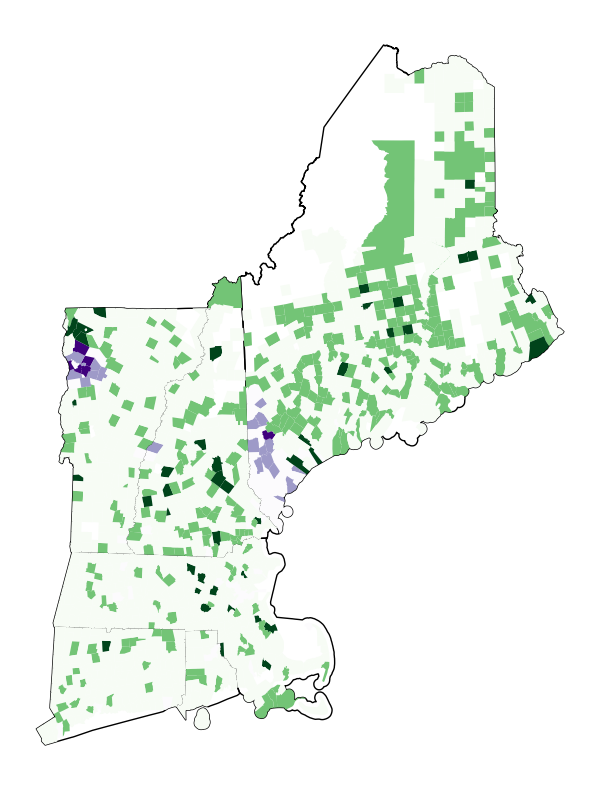

In [10]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

ct_state = gpd.read_file(states.CT.shapefile_urls()['state'])
me_state = gpd.read_file(states.ME.shapefile_urls()['state'])
ma_state = gpd.read_file(states.MA.shapefile_urls()['state'])
nh_state = gpd.read_file(states.NH.shapefile_urls()['state'])
ri_state = gpd.read_file(states.RI.shapefile_urls()['state'])
vt_state = gpd.read_file(states.VT.shapefile_urls()['state'])

ct_state.plot(ax=ax, facecolor='none')
me_state.plot(ax=ax, facecolor='none')
ma_state.plot(ax=ax, facecolor='none')
nh_state.plot(ax=ax, facecolor='none')
ri_state.plot(ax=ax, facecolor='none')
vt_state.plot(ax=ax, facecolor='none')

cousub_gdf.loc[cousub_gdf['nems']==True].plot(ax=ax, column='most_age', cmap='Purples')
cousub_gdf.loc[cousub_gdf['nems']==False].plot(ax=ax, column='most_age', cmap='Greens')